# P05. Visualização de variáveis de processo

Uma corrida real de uma linha de produção de duas etapas, vista só por gráficos. Quero responder três coisas: o processo está no alvo, ele se mantém estável ao longo do tempo, e que variáveis de máquina mudam junto com ele. O centro do notebook é uma carta de controle que compara cada medição com o alvo da máquina.

Escolho o gráfico pela pergunta: linha para o comportamento no tempo, histograma para a distribuição do erro, barras para comparar pontos de medição.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import estilo
from estilo import (AZUL, LARANJA, VERDE_AGUA, CRITICO, TINTA, TINTA_2, TINTA_3,
                    SUPERFICIE, CINZA_FORA, num)

estilo.aplica_tema()

## Os dados

*Multi-stage continuous-flow manufacturing process* (Kaggle, `supergus`): uma corrida de cerca de 4 horas numa linha contínua de duas etapas, com uma leitura por segundo. O fornecedor não diz de que empresa ou setor vem, o dado é anonimizado.

Na Etapa 1, as máquinas 1, 2 e 3 trabalham em paralelo e alimentam um combinador, e a saída dele é medida em 15 pontos, em mm. Na Etapa 2, as máquinas 4 e 5 trabalham em série e a saída é medida nos mesmos 15 pontos. Cada ponto tem duas colunas, o valor medido (`.Actual`) e o alvo (`.Setpoint`).

Nas variáveis das máquinas, `.C.` quer dizer variável controlada, presa num valor fixo por um controlador, e `.U.` quer dizer não controlada. O "C" não é Celsius.

Uso só a Etapa 1.

In [2]:
df = pd.read_csv("../data/continuous_factory_process.csv", parse_dates=["time_stamp"])
df.shape

(14088, 116)

In [3]:
df.head()

,time_stamp,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,...,Stage2.Output.Measurement10.U.Actual,Stage2.Output.Measurement10.U.Setpoint,Stage2.Output.Measurement11.U.Actual,Stage2.Output.Measurement11.U.Setpoint,Stage2.Output.Measurement12.U.Actual,Stage2.Output.Measurement12.U.Setpoint,Stage2.Output.Measurement13.U.Actual,Stage2.Output.Measurement13.U.Setpoint,Stage2.Output.Measurement14.U.Actual,Stage2.Output.Measurement14.U.Setpoint
0,2019-03-06 10:52:33,17.24,23.53,11.54,200,963.0,247,1241.26,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
1,2019-03-06 10:52:34,17.24,23.53,11.54,200,963.0,247,1246.09,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
2,2019-03-06 10:52:35,17.24,23.53,11.54,200,963.0,247,1246.29,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
3,2019-03-06 10:52:36,17.24,23.53,11.54,200,963.0,247,1247.59,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
4,2019-03-06 10:52:37,17.24,23.53,11.54,200,963.0,247,1252.83,72.1,72.4,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14088 entries, 0 to 14087
Columns: 116 entries, time_stamp to Stage2.Output.Measurement14.U.Setpoint
dtypes: datetime64[us](1), float64(108), int64(7)
memory usage: 12.5 MB


In [5]:
df.isna().sum().sum()

np.int64(0)

São 14.088 linhas (uma por segundo, das 10:52 às 14:47 do dia 06/03/2019) e 116 colunas. Nenhum
valor faltando. Isso não quer dizer que o dado esteja limpo: um sensor que falha nem sempre deixa
a célula vazia, às vezes grava zero.

## Um ponto de medição, de perto

Começo pelo ponto 0 da Etapa 1. O alvo dele é 13,75 mm.

In [6]:
MEDIDO = "Stage1.Output.Measurement0.U.Actual"
ALVO = "Stage1.Output.Measurement0.U.Setpoint"

df[MEDIDO].describe()

count    14088.000000
mean        12.896919
std          0.934228
min          0.000000
25%         12.890000
50%         12.970000
75%         13.050000
max         20.880000
Name: Stage1.Output.Measurement0.U.Actual, dtype: float64

A metade central dos dados (do `25%` ao `75%`) cabe em 0,16 mm, de 12,89 a 13,05. Com uma faixa
dessas, o desvio-padrão deveria ficar perto de 0,12. Ele está em 0,93, umas oito vezes maior. O
mínimo (0) e o máximo (20,88) puxam essa conta: o desvio-padrão eleva cada distância ao quadrado,
e poucos pontos muito longe dominam o resultado.

In [7]:
(df[MEDIDO] == 0).sum()

np.int64(70)

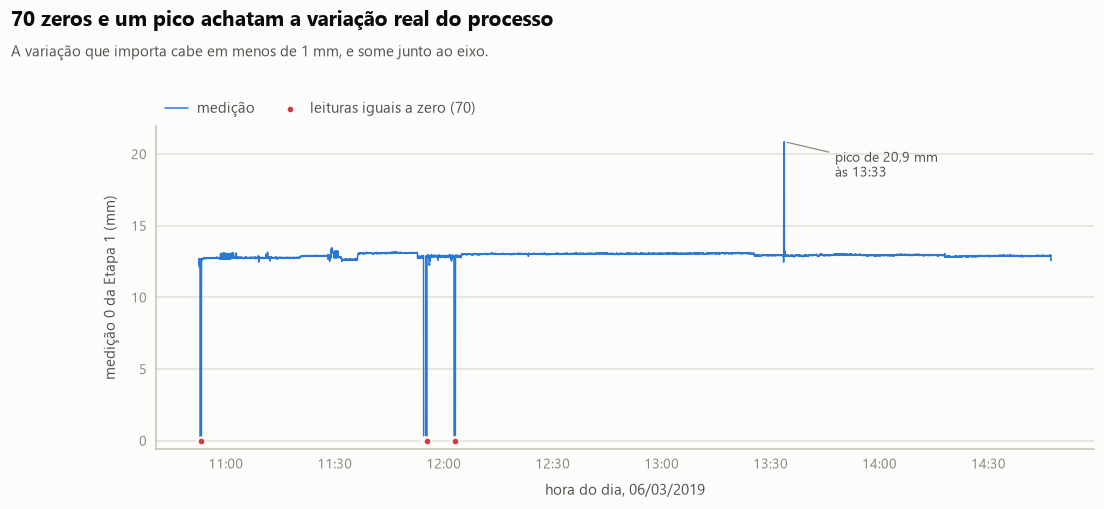

In [8]:
zeros = df[MEDIDO] == 0
t_pico = df.loc[df[MEDIDO].idxmax(), "time_stamp"]

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(df["time_stamp"], df[MEDIDO], color=AZUL, lw=1, label="medição")
ax.scatter(df.loc[zeros, "time_stamp"], df.loc[zeros, MEDIDO], s=24, color=CRITICO,
           edgecolor=SUPERFICIE, linewidth=1.2, zorder=3,
           label=f"leituras iguais a zero ({zeros.sum()})")
estilo.anota(ax, "pico de 20,9 mm\nàs 13:33", xy=(t_pico, 20.88),
             xytext=(t_pico + pd.Timedelta(minutes=14), 19.2))
ax.set_ylim(-0.6, 22)
ax.set_ylabel("medição 0 da Etapa 1 (mm)")
estilo.eixo_tempo(ax)
estilo.legenda(ax)
estilo.titulo(fig, "70 zeros e um pico achatam a variação real do processo",
              "A variação que importa cabe em menos de 1 mm, e some junto ao eixo.")
estilo.salva(fig, "01_zeros_e_pico")
plt.show()

Os 70 zeros são 0,5% das leituras e aparecem em três momentos: 10:52 a 10:53, 11:54 a 11:55 e
12:02 a 12:03. Uma peça de 13 mm não vai a 0 mm de um segundo para o outro, então isso é parada de
linha ou falha de leitura. Os dados não dizem qual das duas, e não vou afirmar. Como zero é
fisicamente impossível aqui, tiro essas linhas.

O pico de 20,88 mm às 13:33:44 é outro caso. É uma leitura plausível, só que anormal. Esse eu
não apago: é exatamente o tipo de ponto que a carta de controle mais abaixo existe para acusar.

In [9]:
sem_zeros = df[df[MEDIDO] > 0]
sem_zeros.shape

(14018, 116)

## Medido contra o alvo

Sem os zeros, o eixo pode se ajustar ao processo de verdade. Desenho o medido e o alvo juntos.

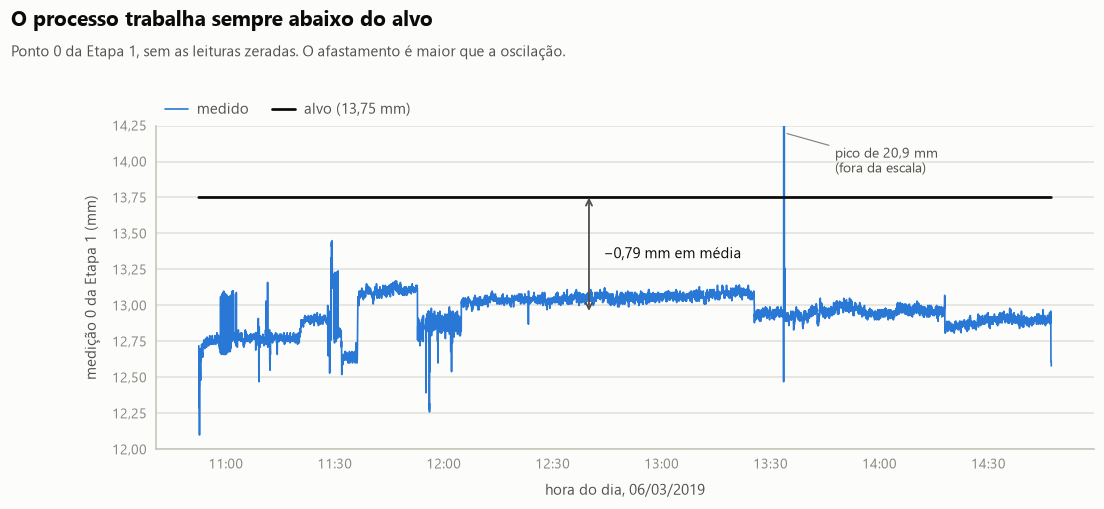

In [10]:
erro = sem_zeros[MEDIDO] - sem_zeros[ALVO]      # erro = medido - alvo
t_seta = pd.Timestamp("2019-03-06 12:40")

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(sem_zeros["time_stamp"], sem_zeros[MEDIDO], color=AZUL, lw=1.1, label="medido")
ax.plot(sem_zeros["time_stamp"], sem_zeros[ALVO], color=TINTA, lw=1.8, label="alvo (13,75 mm)")
ax.annotate("", xy=(t_seta, 13.75 + erro.mean()), xytext=(t_seta, 13.75),
            arrowprops=dict(arrowstyle="<->", color=TINTA_2, lw=1.2, shrinkA=0, shrinkB=0))
ax.text(t_seta + pd.Timedelta(minutes=4), 13.75 + erro.mean() / 2,
        f"{num(erro.mean())} mm em média", va="center", fontsize=10, color=TINTA)
estilo.anota(ax, "pico de 20,9 mm\n(fora da escala)", xy=(t_pico, 14.2),
             xytext=(t_pico + pd.Timedelta(minutes=14), 14.0))
ax.set_ylim(12.0, 14.25)
estilo.formato_br(ax, "y", 2)
ax.set_ylabel("medição 0 da Etapa 1 (mm)")
estilo.eixo_tempo(ax)
estilo.legenda(ax)
estilo.titulo(fig, "O processo trabalha sempre abaixo do alvo",
              "Ponto 0 da Etapa 1, sem as leituras zeradas. O afastamento é maior que a oscilação.")
estilo.salva(fig, "02_medido_contra_alvo")
plt.show()

In [11]:
erro.describe()

count    14018.000000
mean        -0.788680
std          0.205788
min         -1.650000
25%         -0.860000
50%         -0.780000
75%         -0.700000
max          7.130000
dtype: float64

O erro médio é −0,79 mm, cerca de 6% do alvo, e a mediana (−0,78) quase não difere dele. As
leituras não se espalham ao acaso em torno de 13,75. Todas se deslocam para o mesmo lado, como
uma balança descalibrada: é erro sistemático, e não aleatório.

Também aparecem degraus: o nível do medido muda de forma brusca em alguns horários e
permanece ali por um tempo. Isso volta mais abaixo.

## A distribuição do erro

Para ver como o erro se distribui, o gráfico certo é o histograma, com a curva de densidade
por cima. Deixo de fora os 11 pontos do pico (erro acima de zero) só nesta figura, porque eles
esticariam o eixo e achatariam todo o resto.

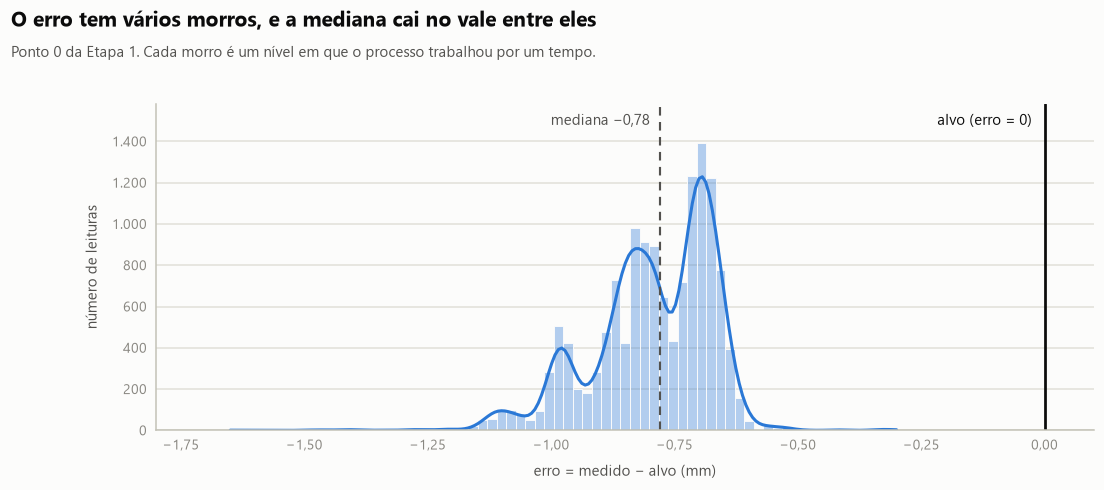

In [12]:
erro_central = erro[erro < 0]

fig, ax = plt.subplots(figsize=(11, 4.4))
sns.histplot(erro_central, bins=70, kde=True, color=AZUL, alpha=0.35,
             edgecolor=SUPERFICIE, linewidth=0.6, line_kws={"linewidth": 2}, ax=ax)
ax.set_xlim(-1.8, 0.1)
ax.set_ylim(0, ax.get_ylim()[1] * 1.08)
topo = ax.get_ylim()[1]

ax.axvline(0, color=TINTA, lw=1.8)
ax.text(-0.025, topo * 0.97, "alvo (erro = 0)", ha="right", va="top", fontsize=9.5, color=TINTA)
mediana = erro_central.median()
ax.axvline(mediana, color=TINTA_2, lw=1.4, ls=(0, (4, 3)))
ax.text(mediana - 0.02, topo * 0.97, f"mediana {num(mediana)}", ha="right", va="top",
        fontsize=9.5, color=TINTA_2)

ax.set_xlabel("erro = medido − alvo (mm)")
ax.set_ylabel("número de leituras")
ax.grid(axis="x", visible=False)
estilo.formato_br(ax, "x", 2)
estilo.formato_br(ax, "y", 0)
estilo.titulo(fig, "O erro tem vários morros, e a mediana cai no vale entre eles",
              "Ponto 0 da Etapa 1. Cada morro é um nível em que o processo trabalhou por um tempo.",
              topo=0.95)
estilo.salva(fig, "03_distribuicao_do_erro")
plt.show()

A forma não é a de uma curva normal. Há pelo menos três morros claros, perto de −0,70, −0,83 e
−0,98, e um quarto menor perto de −1,10. A mediana (−0,78) cai no vale entre dois deles: quase
nenhuma leitura tem esse valor, então ela não descreve nenhum estado real do processo. Nenhum
morro chega perto do alvo.

A hipótese é que cada morro é um patamar em que o processo operou por um tempo. O histograma
perde a ordem temporal, e por isso não confirma isso sozinho. A carta de controle, na próxima
seção, coloca o tempo de volta.

## Carta de controle

Controle Estatístico de Processo (SPC) separa dois tipos de variação: a comum (o ruído
natural, sempre presente) e a especial (algo mudou). A carta de controle desenha o erro no
tempo com uma linha central e dois limites, a ±3 desvios-padrão dela. Numa curva normal, só 0,27%
das leituras cairia fora por acaso, então um ponto fora dos limites merece investigação.

O 3σ é convenção (vem do estatístico Walter Shewhart, na Bell Labs, por volta de 1920), um
compromisso entre alarme falso demais (2σ) e alarme de menos (4σ). E vale só se os dados forem
aproximadamente normais e independentes. Os nossos não são: o histograma tem vários morros, e
leituras a 1 Hz, segundo a segundo, são muito correlacionadas. A carta é uma ferramenta de leitura,
e não um teste exato.

Primeira tentativa: limites calculados com todos os dados.

In [13]:
tempo = sem_zeros["time_stamp"]

centro, sigma = erro.mean(), erro.std()
lic, lsc = centro - 3 * sigma, centro + 3 * sigma
fora = (erro > lsc) | (erro < lic)

print(f"centro = {centro:.2f} | sigma = {sigma:.2f} | LIC = {lic:.2f} | LSC = {lsc:.2f}")
print(f"pontos fora dos limites: {fora.sum()} de {len(erro)}")

centro = -0.79 | sigma = 0.21 | LIC = -1.41 | LSC = -0.17
pontos fora dos limites: 26 de 14018


São 26 pontos fora. Olhando onde estão: 11 no pico (13:33:38 a 13:33:47, dez segundos) e 15 nos
primeiros segundos da corrida (10:52) e por volta de 11:56, logo antes de uma das quedas a zero.
Parecem transitórios de partida e de parada. Em quase 4 horas de corrida, a carta acusou uns 25
segundos, e nenhum dos degraus: os patamares ficaram quase todos dentro de −1,41 a −0,17.

O motivo é que a régua foi calculada com dados que já continham as mudanças de nível, então os
limites acomodam justamente o problema que deveriam denunciar. O desvio-padrão (0,21) também está
inflado pelo pico.

Segunda tentativa: a prática do SPC é calcular os limites de um trecho de referência em que o
processo está estável, e aplicá-los à corrida inteira. Escolhi das 12:10 às 13:20: é o trecho mais
longo e calmo, e começa depois que a máquina 3 terminou de esquentar (ver seção 5). A escolha é um
julgamento meu, e as duas cartas abaixo mostram a diferença.

In [14]:
inicio, fim = pd.Timestamp("2019-03-06 12:10"), pd.Timestamp("2019-03-06 13:20")
janela = (tempo >= inicio) & (tempo <= fim)
referencia = erro[janela]

centro_ref, sigma_ref = referencia.mean(), referencia.std()
lic_ref, lsc_ref = centro_ref - 3 * sigma_ref, centro_ref + 3 * sigma_ref
fora_ref = (erro > lsc_ref) | (erro < lic_ref)

print(f"trecho de referência: {len(referencia)} pontos")
print(f"centro = {centro_ref:.3f} | sigma = {sigma_ref:.3f} | LIC = {lic_ref:.3f} | LSC = {lsc_ref:.3f}")
print(f"fora dos limites na corrida inteira: {fora_ref.sum()} de {len(erro)}")
print(f"fora dos limites dentro do próprio trecho: {fora_ref[janela].sum()} de {len(referencia)}")

trecho de referência: 4201 pontos
centro = -0.697 | sigma = 0.025 | LIC = -0.772 | LSC = -0.621
fora dos limites na corrida inteira: 7585 de 14018
fora dos limites dentro do próprio trecho: 20 de 4201


In [15]:
def desenha_carta(ax, tempo, erro, centro, lic, lsc, janela=None):
    # erro no tempo, linha central, limites de controle e pontos fora deles
    fora = (erro > lsc) | (erro < lic)
    if janela is not None:
        ax.axvspan(*janela, color="#efeee9", zorder=0)
    ax.plot(tempo, erro, color=AZUL, lw=0.9, zorder=2)
    ax.scatter(tempo[fora], erro[fora], s=4, color=CRITICO, alpha=0.5, linewidths=0, zorder=3)
    x0, x1 = tempo.min(), tempo.max()
    ax.hlines(centro, x0, x1, color=TINTA_2, lw=1.2, zorder=1)
    ax.hlines([lsc, lic], x0, x1, color=TINTA_2, lw=1, ls=(0, (4, 3)), zorder=1)
    return fora


legenda_carta = [
    Line2D([], [], color=AZUL, lw=1.6, label="erro (medido − alvo)"),
    Line2D([], [], color=CRITICO, marker="o", ls="", ms=5, label="ponto fora dos limites"),
    Line2D([], [], color=TINTA_2, lw=1.2, label="linha central"),
    Line2D([], [], color=TINTA_2, lw=1, ls=(0, (4, 3)), label="limites ±3σ"),
    Patch(color="#efeee9", label="trecho de referência"),
]

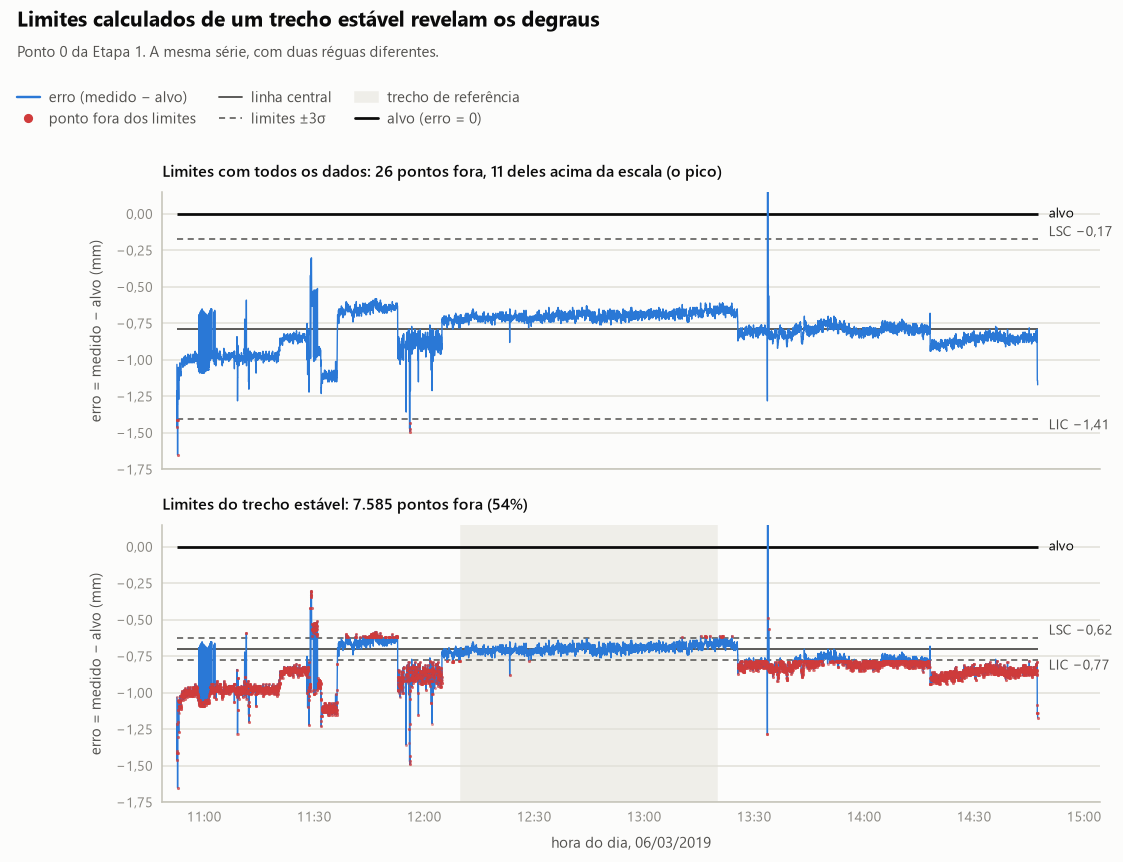

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8.2), sharex=True)
desenha_carta(ax1, tempo, erro, centro, lic, lsc)
desenha_carta(ax2, tempo, erro, centro_ref, lic_ref, lsc_ref, janela=(inicio, fim))

acima = (erro > 0.15).sum()
ax1.set_title(f"Limites com todos os dados: {fora.sum()} pontos fora, {acima} deles acima da escala (o pico)",
              loc="left", fontsize=10.5, fontweight="semibold", color=TINTA, pad=10)
ax2.set_title(f"Limites do trecho estável: {num(fora_ref.sum(), 0)} pontos fora ({fora_ref.mean():.0%})",
              loc="left", fontsize=10.5, fontweight="semibold", color=TINTA, pad=10)

x_rotulo = tempo.max() + pd.Timedelta(minutes=3)
for ax, lic_, lsc_ in ((ax1, lic, lsc), (ax2, lic_ref, lsc_ref)):
    ax.hlines(0, tempo.min(), tempo.max(), color=TINTA, lw=1.8, zorder=1)
    ax.text(x_rotulo, 0, "alvo", va="center", fontsize=9, color=TINTA)
    ax.text(x_rotulo, lsc_, f"LSC {num(lsc_)}", va="bottom", fontsize=9, color=TINTA_2)
    ax.text(x_rotulo, lic_, f"LIC {num(lic_)}", va="top", fontsize=9, color=TINTA_2)
    ax.set_ylim(-1.75, 0.15)
    estilo.formato_br(ax, "y", 2)
    ax.set_xlim(tempo.min() - pd.Timedelta(minutes=4), tempo.max() + pd.Timedelta(minutes=17))
    ax.set_ylabel("erro = medido − alvo (mm)")
    estilo.eixo_tempo(ax, rotulo=False)
estilo.eixo_tempo(ax2)

estilo.titulo(fig, "Limites calculados de um trecho estável revelam os degraus",
              "Ponto 0 da Etapa 1. A mesma série, com duas réguas diferentes.", topo=1.75)
estilo.legenda_figura(fig, legenda_carta + [Line2D([], [], color=TINTA, lw=1.8, label="alvo (erro = 0)")],
                      y=0.78, ncol=3)
estilo.salva(fig, "04_carta_de_controle")
plt.show()

Com a régua do trecho estável, o sigma cai de 0,21 para 0,025, oito vezes menor: agora ele mede só o ruído natural de uma hora calma, sem degraus nem picos. Ficam fora dos limites 54% da corrida (7.585 de 14.018 leituras), e a carta passa a mostrar as mudanças de nível, por volta de 11:00, 11:30, 11:37, 11:53, 12:04 e 13:25, e mudanças menores perto de 11:20 e 14:17. Como teste de sanidade, dentro do próprio trecho de referência só 20 de 4.201 pontos (0,48%) escapam, perto dos 0,27% teóricos.

O 54% mistura duas coisas. Parte é mudança de regime de verdade. Parte vem de eu ter escolhido como régua o trecho mais quieto: um patamar estável em outro nível, com ruído próprio, cruza limites tão apertados. Depois de 13:25, por exemplo, o processo fica calmo, só que em −0,80 a −0,87 mm, um nível diferente do de referência.

O alvo (0) fica fora dos limites nas duas cartas. Estável e no alvo são coisas diferentes, como precisão e exatidão numa medida de laboratório: aqui o processo é consistente por trechos e centrado no lugar errado.

## O que andou junto com os degraus

A carta diz que algo mudou, mas não o quê. Os dados trazem os sensores das máquinas, então dá
para procurar pistas. As variáveis `.C.` (controladas) não ajudam: ficam presas no valor fixado
(a `Zone1Temperature` da máquina 1 fica em 72,0 com desvio-padrão de 0,06), e o gráfico seria uma
reta. As variáveis `.U.` (não controladas) variam. Uso a temperatura e a pressão do material
das máquinas 1, 2 e 3. O dataset não informa as unidades.

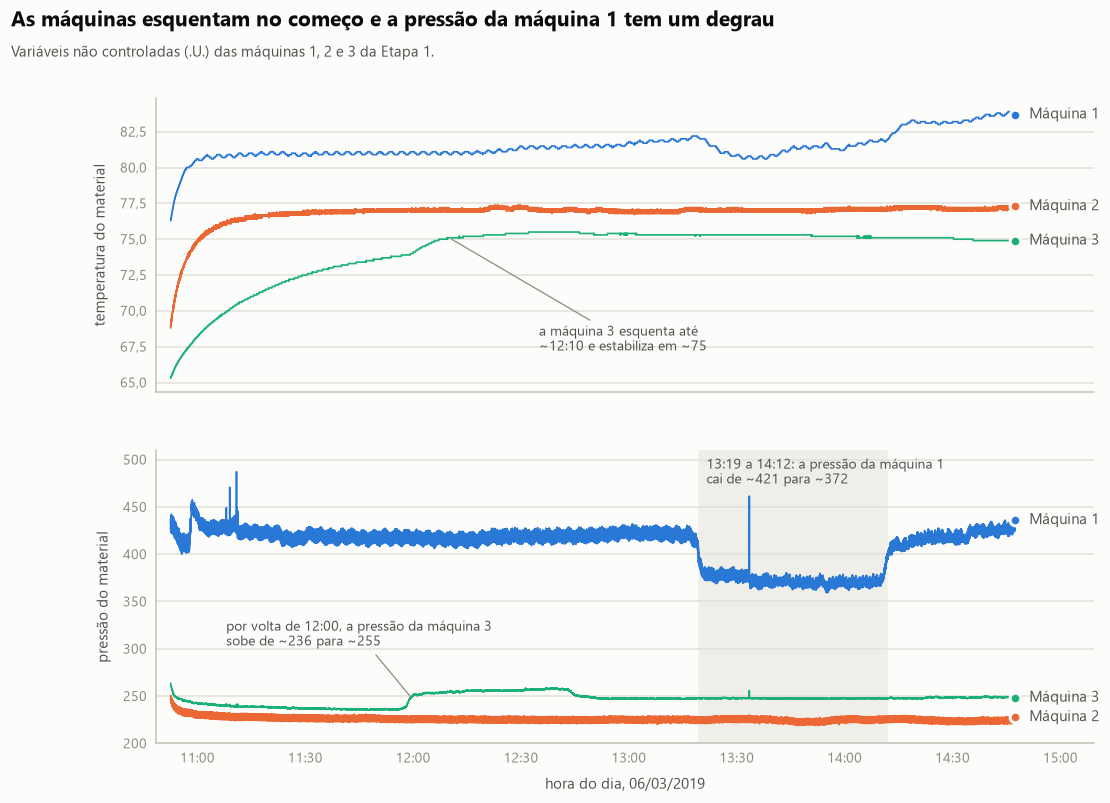

In [17]:
t_fim = df["time_stamp"].iloc[-1]
queda_m1 = (pd.Timestamp("2019-03-06 13:19:34"), pd.Timestamp("2019-03-06 14:11:44"))

fig, (ax_t, ax_p) = plt.subplots(2, 1, figsize=(11, 7.6), sharex=True)
for m, cor in zip((1, 2, 3), estilo.SERIES):
    for ax, coluna in ((ax_t, f"Machine{m}.MaterialTemperature.U.Actual"),
                       (ax_p, f"Machine{m}.MaterialPressure.U.Actual")):
        ax.plot(df["time_stamp"], df[coluna], color=cor, lw=1.1)
        ax.plot(t_fim, df[coluna].iloc[-1], "o", color=cor, ms=7, mec=SUPERFICIE, mew=2)
        ax.text(t_fim + pd.Timedelta(minutes=4), df[coluna].iloc[-1], f"Máquina {m}",
                va="center", fontsize=9.5, color=TINTA_2)

ax_p.axvspan(*queda_m1, color="#efeee9", zorder=0)
ax_p.text(queda_m1[0] + pd.Timedelta(minutes=2), 502,
          "13:19 a 14:12: a pressão da máquina 1\ncai de ~421 para ~372",
          va="top", fontsize=9, color=TINTA_2)
estilo.anota(ax_p, "por volta de 12:00, a pressão da máquina 3\nsobe de ~236 para ~255",
             xy=(pd.Timestamp("2019-03-06 12:00"), 246), xytext=(pd.Timestamp("2019-03-06 11:08"), 315))
estilo.anota(ax_t, "a máquina 3 esquenta até\n~12:10 e estabiliza em ~75",
             xy=(pd.Timestamp("2019-03-06 12:10"), 75.1), xytext=(pd.Timestamp("2019-03-06 12:35"), 68))

for ax in (ax_t, ax_p):
    ax.set_xlim(df["time_stamp"].iloc[0] - pd.Timedelta(minutes=4), t_fim + pd.Timedelta(minutes=22))
    estilo.eixo_tempo(ax, rotulo=False)
estilo.eixo_tempo(ax_p)
ax_t.set_ylabel("temperatura do material")
ax_p.set_ylabel("pressão do material")
ax_p.set_ylim(200, 510)
estilo.formato_br(ax_t, "y", 1)
estilo.formato_br(ax_p, "y", 0)
estilo.titulo(fig, "As máquinas esquentam no começo e a pressão da máquina 1 tem um degrau",
              "Variáveis não controladas (.U.) das máquinas 1, 2 e 3 da Etapa 1.", topo=0.9)
estilo.salva(fig, "05_temperatura_e_pressao")
plt.show()

As três máquinas partem frias e sobem rápido no começo, devagar depois, como qualquer sistema térmico indo ao equilíbrio. A máquina 3 é a mais lenta e só chega ao patamar (~75) por volta de 12:10, o que é um argumento para o trecho de referência começar depois disso.

A pressão da máquina 1 fica em ~421, cai para ~372 às 13:19 e volta a ~417 às 14:12. Ela também é a mais agitada das três, com oscilação e picos isolados. A da máquina 3 sobe de ~236 para ~255 por volta de 12:00.

Os horários se encaixam com o que a carta mostrou. O erro muda de patamar por volta de 12:04, perto do degrau de pressão da máquina 3, e por volta de 13:25, seis minutos depois da queda de pressão da máquina 1. O pico do erro (13:33) coincide com picos de pressão na máquina 1.

Isso é coincidência de horário, não prova de causa. Testar se a relação existe de fato pede um teste de hipóteses, e um mapa de correlação simples enganaria: séries com tendência, como o aquecimento, parecem correlacionadas só porque sobem juntas com o tempo.

## Nem todo ponto de medição serve

Até aqui olhei só o ponto 0. Antes de estender para os outros 14, confiro a premissa que usei:
que zero é falha.

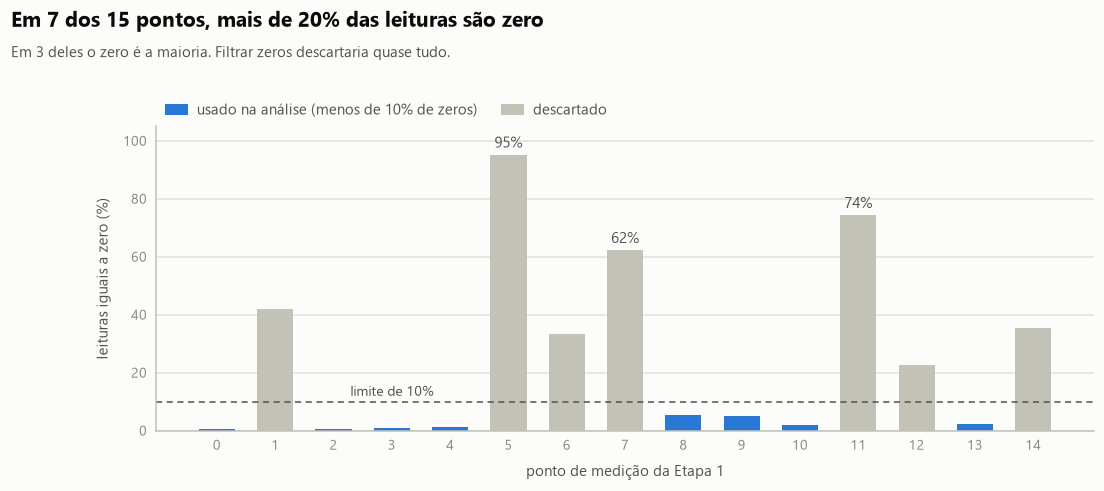

In [18]:
colunas_medido = [f"Stage1.Output.Measurement{p}.U.Actual" for p in range(15)]
pct_zeros = (df[colunas_medido] == 0).mean() * 100
pct_zeros.index = range(15)
usaveis = pct_zeros < 10

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.bar(pct_zeros.index[usaveis], pct_zeros[usaveis], width=0.62, color=AZUL,
       label="usado na análise (menos de 10% de zeros)")
ax.bar(pct_zeros.index[~usaveis], pct_zeros[~usaveis], width=0.62, color=CINZA_FORA,
       label="descartado")
ax.axhline(10, color=TINTA_2, lw=1, ls=(0, (4, 3)), zorder=1)
ax.text(3, 11, "limite de 10%", ha="center", va="bottom", fontsize=9, color=TINTA_2)
for p in pct_zeros.index[pct_zeros > 50]:
    ax.text(p, pct_zeros[p] + 1.5, f"{pct_zeros[p]:.0f}%", ha="center", va="bottom",
            fontsize=9.5, color=TINTA_2)
ax.set_xticks(range(15))
ax.grid(axis="x", visible=False)
ax.set_ylim(0, 105)
estilo.formato_br(ax, "y", 0)
ax.set_xlabel("ponto de medição da Etapa 1")
ax.set_ylabel("leituras iguais a zero (%)")
estilo.legenda(ax)
estilo.titulo(fig, "Em 7 dos 15 pontos, mais de 20% das leituras são zero",
              "Em 3 deles o zero é a maioria. Filtrar zeros descartaria quase tudo.")
estilo.salva(fig, "06_zeros_por_ponto")
plt.show()

In [19]:
usaveis[usaveis].index.tolist()

[0, 2, 3, 4, 8, 9, 10, 13]

Em 7 pontos os zeros são mais de 20% das leituras, e em 3 (os pontos 5, 7 e 11) são a maioria: o
ponto 5 tem 95%. Nesses, zero é o estado normal, provavelmente porque o ponto não estava sendo
medido, e a regra "zero é falha" não vale.
Não sei o motivo, e por isso trato como pontos com pouca cobertura, sem afirmar defeito de sensor.

Uso só os pontos com menos de 10% de zeros: 0, 2, 3, 4, 8, 9, 10 e 13. O corte em 10% é uma escolha
minha. Empacoto o cálculo do erro numa função e confiro que ela reproduz o ponto 0 que já fiz.

In [20]:
def calcula_erro(ponto):
    base = f"Stage1.Output.Measurement{ponto}.U"
    medido = df[f"{base}.Actual"]
    alvo = df[f"{base}.Setpoint"]
    valido = (medido > 0) & (alvo > 0)
    return (medido - alvo)[valido]


calcula_erro(0).equals(erro)

True

## Vários pontos, a mesma corrida

Coloco quatro pontos um sobre o outro, com o mesmo eixo de tempo e a carta de controle de cada um
(limites de ±3σ do mesmo trecho de referência). Se as mudanças de nível vierem de algo comum,
elas aparecem alinhadas na vertical.

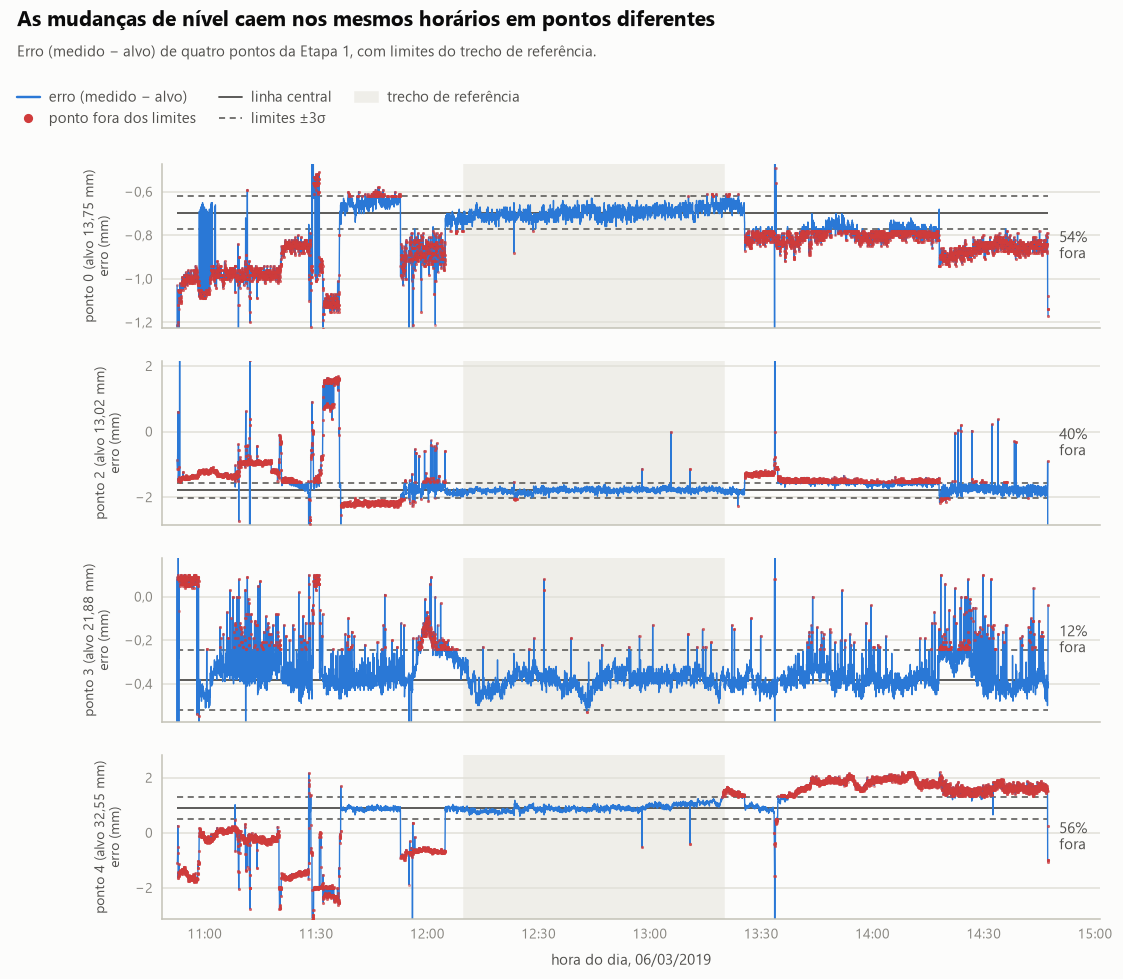

In [21]:
pontos = [0, 2, 3, 4]

fig, eixos = plt.subplots(len(pontos), 1, figsize=(11, 9.4), sharex=True)
for ax, p in zip(eixos, pontos):
    erro_p = calcula_erro(p)
    tempo_p = df.loc[erro_p.index, "time_stamp"]
    ref = erro_p[(tempo_p >= inicio) & (tempo_p <= fim)]
    c, s = ref.mean(), ref.std()
    fora_p = desenha_carta(ax, tempo_p, erro_p, c, c - 3 * s, c + 3 * s, janela=(inicio, fim))

    baixo, alto = erro_p.quantile([0.005, 0.995])
    margem = 0.15 * (alto - baixo)
    ax.set_ylim(baixo - margem, alto + margem)
    ax.set_xlim(tempo.min() - pd.Timedelta(minutes=4), tempo.max() + pd.Timedelta(minutes=14))
    alvo_p = df[f"Stage1.Output.Measurement{p}.U.Setpoint"].max()
    ax.set_ylabel(f"ponto {p} (alvo {num(alvo_p)} mm)\nerro (mm)", fontsize=9)
    estilo.formato_br(ax, "y", 1 if p in (0, 3) else 0)
    ax.text(tempo.max() + pd.Timedelta(minutes=3), np.mean([baixo, alto]), f"{fora_p.mean():.0%}\nfora",
            va="center", fontsize=9.5, color=TINTA_2)
    estilo.eixo_tempo(ax, rotulo=False)
estilo.eixo_tempo(eixos[-1])

estilo.titulo(fig, "As mudanças de nível caem nos mesmos horários em pontos diferentes",
              "Erro (medido − alvo) de quatro pontos da Etapa 1, com limites do trecho de referência.",
              topo=1.5)
estilo.legenda_figura(fig, legenda_carta, y=0.78, ncol=3)
estilo.salva(fig, "07_varios_pontos")
plt.show()

As mudanças de nível caem nos mesmos horários nos pontos 0, 2 e 4, por volta de 11:00, 11:30, 12:04 e 13:25, e o pico de 13:33 aparece nos quatro. Eventos alinhados atingindo pontos diferentes ao mesmo tempo sugerem uma causa comum, antes das medições, e não defeitos independentes em cada ponto. A direção do efeito varia: às 13:25 o ponto 0 desce um pouco (de −0,70 para −0,80) e o ponto 2 sobe bastante (de −1,85 para −1,30).

Cada ponto conta uma história diferente. O ponto 0 fica abaixo do alvo o tempo todo, em patamares. O ponto 2 é o mais afastado, com erro médio de −1,59 mm (12% do alvo), e tem picos isolados que o ponto 0 não tem, dois deles dentro do trecho de referência. O ponto 3 é o mais próximo do alvo (erro médio de −0,35 mm) e o que menos muda de nível. O que muda nele é a variabilidade, com rajadas de picos no começo e depois de 14:15, e só 12% da corrida fica fora dos limites. No ponto 4 o erro atravessa o zero: começa em cerca de −1,5 mm, passa a positivo por volta de 11:37 (mediana de +0,9 até 13:20, com uma volta a −0,6 entre 11:56 e 12:02) e termina em torno de +1,6 mm. O processo sai de abaixo do alvo para acima dele, e olhar só o ponto 0 esconderia isso.

## Conclusões

O processo não está no alvo: no ponto 0 o erro é sistemático, de −0,79 mm em média. Também não é estável, porque trabalha em patamares que mudam em horários específicos. Uma carta de controle com limites calculados de todos os dados não vê isso, e com os limites de um trecho estável vê.

Essas mudanças aparecem alinhadas em vários pontos de medição e coincidem com mudanças na pressão das máquinas 1 e 3, o que aponta para uma causa comum. É uma hipótese a testar.

## Limitações

O trecho de referência (12:10 a 13:20) foi escolhido por mim, a olho, e o sigma dele (0,025) vem de uma hora particularmente calma, então o 54% fora dos limites depende dessa escolha. Um sigma robusto a picos, pela mediana dos desvios, seria a próxima comparação. Os limites são calculados e avaliados nos mesmos dados, sem uma segunda corrida para validar.

Leituras a 1 Hz são correlacionadas entre si e a distribuição não é normal, então os 0,27% de alarme falso do 3σ valem só como referência. É uma corrida só, de 4 horas, e não generaliza para a linha.

Não sei a causa dos zeros nem dos picos, e não a afirmo. O mesmo vale para a relação entre pressão e erro: é coincidência de horário, sem teste. Analisei a Etapa 1. A Etapa 2, mais ruidosa segundo a documentação do dataset, e 7 dos 15 pontos ficaram de fora.